<a href="https://colab.research.google.com/github/stephenfrein/vucsc8491/blob/main/Week1_EDA_and_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1: Exploratory Data Analysis / Data Cleaning

## The Goal of Exploratory Data Analysis (EDA)

The goal of exploratory data analysis is to get familiar with the data you will be analyzing so you can make smart choices during your analysis.

The data **will** surprise you - understanding its basic characteristics is how you will start understanding the problem you're tying to solve, the tools you have to solve it, and the challenges you're likely to encounter.

Effective data mining requires some understanding of the problem domain - without it, your analysis will likely generate laughable and/or inaccurate conclusions.

*Story Time: MRC analysis at Comcast*

##Pandas for Tabular Data

Most data mining algorithms and methods require that you'll be using tabular data ("rectangular" data arranged in rows and columns, equivalent to what you'd find in a relational database like Oracle / SQL Server / MySQL / Postgres / etc).

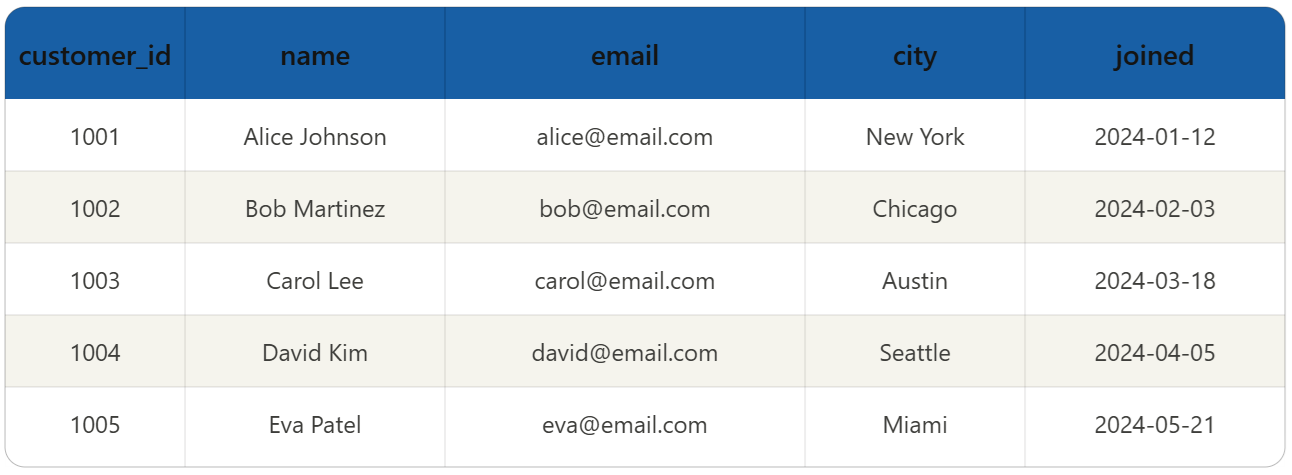


*Pandas* is the most commonly used library for handling tabular data in Python. The name comes from a combination of "panel data" (a term for data sets often used in econometrics) and "data analysis."

We're going to use pandas to read into memory a copy of a famous dataset about passengers on the Titanic, fittingly known as the *Titanic Dataset*. This dataset is commonly used to begin learning about data mining and/or new model-building algorithms.

In pandas, a tabular dataset is called a *DataFrame*. In practice, people will often drop the capitalization and just refer to a *dataframe*.

In [ ]:
# lines preceded by a hash (pound sign) are comments

# in Python, when we want to use a library, we have to import it
# it's idiomatic (conventional) to alias pandas as pd for short
import pandas as pd
# read_csv is a pandas method that reads a comma-separate values (csv) file
# it returns a DataFrame full of the data, which we're naming "titanic_df"
titanic_df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

### A Note About Colab

Colab is based on *Jupyter* notebooks, which allow you to define runnable "cells" of Python code intermixed with static web content (like what you're reading right now) and visualizations.

The variables you define in memory persist across cells, so you'll be able to keep referring to your *titanic_df* dataframe below. Your work will stay in memory as long as you're connected to the same runtime (look for the words "RAM" and "Disk" in the upper right of your browser to see some stats on the runtime you're using right now). If your runtime gets disconnected, usually due to inactivity, all of the work you previously did is gone, and you'll need to rerun previously run code to recreate that work.

## Starting to Explore

Let's take our first steps in exploring the Titanic dataset to get familiar with what it contains. We'll start with some basic questions:

* how many rows and columns does it contain?
* what do some sample rows look like?
* how is the data typed?
* can we summarize the columns statistically?

In [ ]:
# how many rows and columns does the dataframe have?
titanic_df.shape          # (rows, columns)

In [ ]:
# what do the first 5 rows look like?
titanic_df.head()
# how about the last 5?
# titanic_df.tail()
# first 10?
# titanic_df.head(n=10)

# STEVE, show the interactive table features!


In [ ]:
# see data types and non-null counts
# null means "there's no value in in that cell"
# nulls showed up as "NaN" (not a number) in the cell above
titanic_df.info()

# >>> why would we care about non-null counts?

*Ints* are integers (shocking!), *objects* are often string/text values (like "Steve") or dates, and *floats* have a decimal component. We'll also see *bools* (boolean, or true/false) soon.

# Exercise 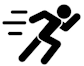

In [ ]:
# there's a csv file called the "Ames Housing Dataset" at https://csc8491.s3.us-east-1.amazonaws.com/AmesHousing.csv
# 1. read it into a Pandas dataframe

In [ ]:
# 2. find out how many rows and columns it has

In [ ]:
# 3. find out which columns have the most null values

# STEVE, show how to add a new Code cell to this notebook

# Mean, Median, and Quartiles

mean_median_quartiles.svg



# Standard Deviation

standard_deviation_definition.svg

In [ ]:
# summary statistics for numeric columns
titanic_df.describe()

# >>> what can you tell from this data?
# >>> Survived, Pclass, Age, Fare to start

## Looking Closer at the Data...

In [ ]:
# how to see a specific row by value?
# [] contains some filter condition for the dataframe
titanic_df[titanic_df['Age'] == 80]

In [ ]:
# let's see what that inner expression above is doing
# returns True or False for each row
# when we feed that into our filter above, we only get "True" rows returned
titanic_df['Age'] == 80

In [ ]:
# how to search for a partial match of a string?
# na=False means "treat null/blank values as if there was no match"
titanic_df[titanic_df['Name'].str.contains('Smith', na=False)]

# to see what happens when na=False isn't used with null values, uncomment next line
# titanic_df[titanic_df['Cabin'].str.contains('A')]

In [ ]:
# find null values
titanic_df[titanic_df['Embarked'].isnull()]

In [ ]:
# search multiple conditions
titanic_df[(titanic_df['Embarked'] == 'Q') & (titanic_df['Pclass'] == 1)]

##Exercise 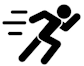

In [ ]:
# find the rows that have an 8 for SibSp

In [ ]:
# find female first-class passengers who don't have a cabin recorded

In [ ]:
# find the rows with a fare greater than $300
# we haven't shown you this yet - take a guess or do a little research

## Duplicate Check

In [ ]:
# are any rows duplicated?
# notice the chained method calls
titanic_df.duplicated().sum()
# the "np.int64()" in the output means "this an integer value from numpy, a library that pandas uses internally"
# zero duplicates here

In [ ]:
# create a test dataframe with duplicate rows just to see how the duplication detection works
dup_df = pd.DataFrame([[1, 'a'], [2, 'b'], [3, 'c'], [1, 'a']], columns=['Number', 'Letter'])

# print() and display() statements help us control what we output
# use display() for richer content
# the numbers in the left column are row indexes
print('Simple version of data frame using print():')
print(dup_df)
print('\n------------------\n') # \n is new line
print('Richer version of data frame using display():')
display(dup_df)
print('\n------------------\n')
# notice what duplicated returns
# seeing bool (boolean, or true/false) for first time
print('duplicated() works row-by-row:')
print(dup_df.duplicated())
print('\n------------------\n')
# notice how sum() works
print('sum() is adding up the true values:')
print(dup_df.duplicated().sum())


In [ ]:
ah_df.duplicated().sum()

## Seeing Distributions

In [ ]:
# Histogram
# loose way to set the number of bins is to use the square root of the number of examples (rows) you have
# titanic_df had about 900 rows
titanic_df['Fare'].hist(bins=30)

**Boxplots**

vertical_boxplot_explainer.svg

In [ ]:
# seaborn is a visualization library
# conventional to import it as sns
import seaborn as sns
# boxplots show 25th, 50th (median), and 75th percentile in box, with "whiskers" showing high/low non-anomalous values
sns.boxplot(data=titanic_df, x='Survived', y='Age')

In [ ]:
# Categorical columns
titanic_df['Pclass'].value_counts().plot(kind='bar')

In [ ]:
# group by first column then calculate stats on second column
titanic_df.groupby('Survived')['Fare'].agg(['mean', 'median', 'std', 'count'])

# Exercise 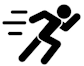

In [ ]:
# for the Ames Housing dataset you pulled down earlier

# 1. does the typical house seem to have a screen porch?
# 2. generate a histogram of prices
# 3. generate a boxplot of prices by Sale Condition
# 4. what kind of Sale Type has the highest median SalePrice?

# add as many code cells as you need, or use display()/print() to show it all from one cell


In [ ]:
#ah_df.head()
#sns.boxplot(data=ah_df, x='Sale Condition', y='SalePrice')
ah_df['SalePrice'].hist(bins=55)

## How do variables relate to one another?

In [ ]:
# correlation matrix
# correlation ranges from -1 (move against each other) to 1 (move together)
titanic_df.corr(numeric_only=True)

# remember - correlation does not equal causation

# what variables had strongest correlation with survival?
# how does age relate to Pclass?

In [ ]:
# heatmap version
sns.heatmap(titanic_df.corr(numeric_only=True), annot=True, cmap='coolwarm')

In [ ]:
# Pair plot (good for small datasets)
sns.pairplot(titanic_df)

In [ ]:
!pip install pivottablejs
from pivottablejs import pivot_ui
# it takes some odd steps to get this to render directly in Colab
# so we're just going to write a file we can download from Files (the Folder) on the left
pivot_ui(titanic_df, outfile_path='titanic_pivot.html')

# Exercise 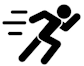

In [ ]:
# for Ames Housing data (ah_df), which variables are most strongly correlated with Sale Price
# try using a heatmap
ah_df.corr(numeric_only=True)
sns.pairplot(ah_df)

In [ ]:
#!pip install ydata_profiling
from ydata_profiling import ProfileReport
ProfileReport(titanic_df)

In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/!CSC8491/test.csv')
df.info()